In [1]:
import Pkg
Pkg.activate("./")
Pkg.instantiate()

  Activating project at `~/Desktop/git_projects/Causal sets/CausalSetZoology/analysis`


In [4]:
using Revise
using Statistics
using CairoMakie
using LinearAlgebra
using LinearAlgebra
using Base.Threads
using Arpack
import JLD2
includet("analysis.jl")

In [3]:
function fig_path(fig_name::String)
        #path = "/Users/fabianwagner/Dropbox/Fabian/Research/Shared Folders/CausalSetZoology/figs/"
        path = "/Users/fabian/Dropbox/Fabian/Research/Shared Folders/CausalSetZoology/figs/"
        return "$(path)$(fig_name)"
end

fig_path (generic function with 1 method)

In [5]:
struct NormalizedLinkLaplacianOp <: AbstractMatrix{Float64}
    cset::SparseLinksCauset
    dinvsqrt::Vector{Float64}
end

Base.size(L::NormalizedLinkLaplacianOp) =
    (L.cset.atom_count, L.cset.atom_count)

Base.eltype(::Type{NormalizedLinkLaplacianOp}) = Float64
Base.eltype(::NormalizedLinkLaplacianOp) = Float64

LinearAlgebra.issymmetric(::NormalizedLinkLaplacianOp) = true
LinearAlgebra.ishermitian(::NormalizedLinkLaplacianOp) = true
Base.size(L::NormalizedLinkLaplacianOp, d::Int) = d <= 2 ? L.cset.atom_count : 1

In [6]:
function normalized_link_laplacian_operator(cset::SparseLinksCauset)
    n = cset.atom_count

    deg = Vector{Float64}(undef, n)

    @inbounds for i in 1:n
        deg[i] = length(cset.future_links[i]) + length(cset.past_links[i])
    end

    dinvsqrt = zeros(Float64, n)
    @inbounds for i in 1:n
        if deg[i] > 0
            dinvsqrt[i] = inv(sqrt(deg[i]))
        end
    end

    return NormalizedLinkLaplacianOp(cset, dinvsqrt)
end

normalized_link_laplacian_operator (generic function with 1 method)

In [7]:
function LinearAlgebra.mul!(
    y::AbstractVector{Float64},
    L::NormalizedLinkLaplacianOp,
    x::AbstractVector{Float64},
)
    cset = L.cset
    dinv = L.dinvsqrt
    n = cset.atom_count

    @threads :dynamic for i in 1:n
        wi = dinv[i]

        if wi == 0.0
            y[i] = x[i]
            continue
        end

        acc = 0.0

        @inbounds for j in cset.future_links[i]
            acc += dinv[j] * x[j]
        end

        @inbounds for j in cset.past_links[i]
            acc += dinv[j] * x[j]
        end

        y[i] = x[i] - wi * acc
    end

    return y
end

In [8]:
function laplacian_extreme_eigenvalues(links; nev_small = 2, tol = 1e-6)
    Lop = normalized_link_laplacian_operator(links)

    λsmall = eigs(
        Lop;
        nev = nev_small,
        which = :SM,
        tol = tol,
        ritzvec = false,
    )[1]

    λlarge = eigs(
        Lop;
        nev = 1,
        which = :LM,
        tol = tol,
        ritzvec = false,
    )[1]

    λs = sort!(real.(λsmall))

    λ2 = if nev_small == 2
        λs[2]
    else
        first(λ for λ in λs if λ > 1e-10)
    end

    λmax = real(λlarge[1])

    return (λ2, λmax)
end

laplacian_extreme_eigenvalues (generic function with 1 method)

In [9]:
function process_batch_into!(out, f, batch; nev_small = 2, tol = 1e-6)
    links_batch = f["batches"]["$(batch)"]["links"]  # loads one full batch

    sizehint!(out, length(out) + length(links_batch))

    for links in links_batch
        push!(
            out,
            laplacian_extreme_eigenvalues(
                links;
                nev_small = nev_small,
                tol = tol,
            ),
        )
    end

    return out
end

process_batch_into! (generic function with 1 method)

In [10]:
function split_eigval_tuples(eigvals::Vector{Tuple{Float64, Float64}})
    second_ev = Float64[x[1] for x in eigvals]
    last_ev   = Float64[x[2] for x in eigvals]
    return second_ev, last_ev
end

function save_path_result!(outpath::AbstractString, size, eigvals::Vector{Tuple{Float64, Float64}})
    second_ev, last_ev = split_eigval_tuples(eigvals)

    size_key = string(size)

    JLD2.jldopen(outpath, "a+") do f
        f["$size_key/second_ev"] = second_ev
        f["$size_key/last_ev"]   = last_ev
    end

    return nothing
end

save_path_result! (generic function with 1 method)

# Second and last eigenvalues vs Size for Manifoldlike Simply Connected Datasets

This notebook loads all available `manifoldlike_simply_connected_<size>_10000` statistics files,
computes the second and last Laplacian eigenvalue for each sample, and plots the mean eigenvalues with asymmetric error bars as a function of size.

In [9]:
analysis_root_man = "/Volumes/Causal Set Silo/causal_sets/analysis/link_degree_only"

function manifoldlike_size_path_pairs(root::AbstractString)
    pairs = Tuple{Int,String}[]
    for name in readdir(root)
        m = match(r"^manifoldlike_simply_connected_link_degree_(\d+)_1000$", name)
        msm = match(r"^manifoldlike_simply_connected_link_degree_(\d+)_100$", name)
        isnothing(m) && isnothing(msm) && continue

        size = isnothing(m) ? parse(Int, msm.captures[1]) : parse(Int, m.captures[1])
        ispow2(size) || continue
        size < 1024 && continue

        path = joinpath(root, name, "dataset.jld2")
        isfile(path) || continue
        push!(pairs, (size, path))
    end
    sort!(pairs; by = first)
    return pairs
end


size_path_pairs_man = manifoldlike_size_path_pairs(analysis_root_man)
sizes_man = first.(size_path_pairs_man)
paths_man = last.(size_path_pairs_man)

sizes_man

7-element Vector{Int64}:
  1024
  2048
  4096
  8192
 16384
 32768
 65536

In [17]:
outpath = "./evs_size.jld2"

paths_man = [p[2] for p in size_path_pairs_man]
sizes_man = [p[1] for p in size_path_pairs_man]

nbatches_man = [
    JLD2.jldopen(path, "r") do f
        f["meta"]["nbatches"]
    end
    for path in paths_man
]

total_batches = sum(nbatches_man)

p = Progress(total_batches; desc = "Eigenvalues")

eigvals_man = Vector{Vector{Tuple{Float64, Float64}}}(undef, length(paths_man))

for (ipath, (size, path, nbatches)) in enumerate(zip(sizes_man, paths_man, nbatches_man))
    path_results = Tuple{Float64, Float64}[]

    JLD2.jldopen(path, "r") do f
        for batch in 1:nbatches
            ProgressMeter.update!(
                p,
                desc = "size=$size, path=$ipath/$(length(paths_man)), batch=$batch/$nbatches"
            )

            process_batch_into!(
                path_results,
                f,
                batch;
                nev_small = 2,
                tol = 1e-6,
            )

            next!(p)
            GC.gc()
        end
    end

    eigvals_man[ipath] = path_results
    save_path_result!(outpath, size, path_results)
end

size=65536, path=7/7, batch=6/6 100%|████████████████████| Time: 1:45:34


In [ ]:
Lop = normalized_link_laplacian_operator(links)

λsmall = eigs(Lop; nev=2, which=:SM, tol=1e-6, ritzvec=false)[1]

λlarge = eigs(Lop; nev=1, which=:LM, tol=1e-6, ritzvec=false)[1]

λ2 = sort(real.(λsmall))[2]

λmax = real(λlarge[1])

In [45]:
λ₂s = [[vals[1] for vals in val_sets] for val_sets in eigvals_man]
λ₂means = [Statistics.mean(val) for val in λ₂s]
λ₂stds = [Statistics.std(val) for val in λ₂s]

7-element Vector{Float64}:
 0.02537643852462039
 0.022935081134843015
 0.020347121535062615
 0.019138628813540268
 0.017849132510781813
 0.01658748839625746
 0.015503670381238817

In [46]:
λₙs = [[vals[2] for vals in val_sets] for val_sets in eigvals_man]
λₙmeans = [Statistics.mean(val) for val in λₙs]
λₙstds = [Statistics.std(val) for val in λₙs]

7-element Vector{Float64}:
 0.02491899393329725
 0.02411684729930884
 0.023061861273883714
 0.020944276045209553
 0.021128291656714624
 0.019953779593037915
 0.01872534898377169

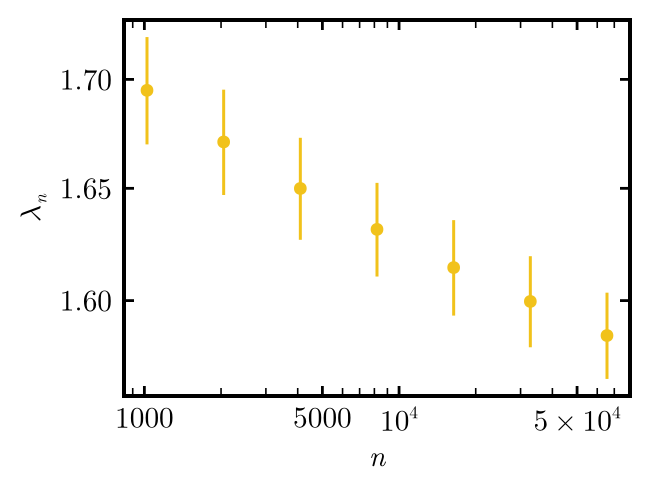

In [47]:
figsize = apply_paper_theme!(; logscale_x=true, logscale_y=true)
fig = Figure(; size = figsize)
ax = Axis(
    fig[1,1];
    xscale = log10,
    yscale = log10,
    yticks = [1.5, 1.55, 1.6, 1.65, 1.7, 1.75],
    xlabel = L"n",
    ylabel = L"\lambda_n")
scatter!(ax, sizes_man, λₙmeans)
errorbars!(ax, sizes_man, λₙmeans, λₙstds)

save(fig_path("graph_observables/last_ev_size.pdf"), fig)

fig

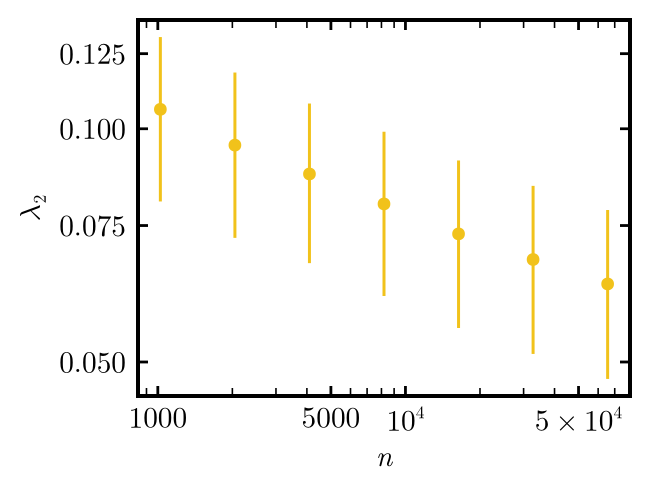

In [48]:
figsize = apply_paper_theme!(; logscale_x=true, logscale_y=true)
fig = Figure(; size = figsize)
ax = Axis(
    fig[1,1];
    xscale = log10,
    yscale = log10,
    yticks = [0.05, 0.075, 0.1, 0.125, 0.15],
    xlabel = L"n",
    ylabel = L"\lambda_2")
scatter!(ax, sizes_man, λ₂means)
errorbars!(ax, sizes_man, λ₂means, λ₂stds)

save(fig_path("graph_observables/second_ev_size.pdf"), fig)

fig

# Second and last eigenvalues vs Size for Minkowski Datasets

In [11]:
analysis_root = "/Volumes/Causal Set Silo/causal_sets/analysis/link_degree_only/"

function minkowski_size_path_pairs(root::AbstractString)
    pairs = Tuple{Int,String}[]
    for name in readdir(root)
        m = match(r"^minkowski_sprinkling_link_degree_(\d+)_1000$", name)
        msm = match(r"^minkowski_sprinkling_link_degree_(\d+)_100$", name)
        isnothing(m) && isnothing(msm) && continue
        size = isnothing(m) ? parse(Int, msm.captures[1]) : parse(Int, m.captures[1])
        path = joinpath(root, name, "dataset.jld2")
        isfile(path) || continue
        push!(pairs, (size, path))
    end
    sort!(pairs; by = first)
    return pairs
end

size_path_pairs_mink = minkowski_size_path_pairs(analysis_root)
sizes_mink = first.(size_path_pairs_mink)
paths_mink = last.(size_path_pairs_mink)

sizes_mink

12-element Vector{Int64}:
    1024
    2048
    4096
    8192
   16384
   32768
   65536
  131072
  262144
  262144
  524288
 1048576

In [27]:
links = Vector{SparseLinksCauset}()
JLD2.jldopen(paths_mink[end], "r") do f
    append!(links, f["batches/1/links"])
end

3-element Vector{SparseLinksCauset}:
 SparseLinksCauset(1048576, Vector{Int32}[[3, 5, 6, 7, 8, 12, 13, 112, 298, 436, 2397, 3585, 13038, 18024, 33397, 63697, 91415], [3, 7, 30, 61, 112, 298, 436, 1331, 72154, 186669], [4, 19, 409, 1122, 1221, 1314, 1358, 19827, 50002, 103589, 161931, 389884], [10, 11, 14, 21, 42, 1003, 1611, 3263, 4940, 8051, 20997, 148445, 288714], [11, 14, 15, 19, 24, 25, 215, 812, 1483, 396458], [11, 14, 15, 19, 30, 61, 163, 215, 453, 712, 1236, 6131, 12923, 13692, 30718, 185365, 213846], [10, 21, 42, 135, 187, 572, 22064, 27743, 421266], [14, 19, 24, 25, 28, 59, 62, 363, 480, 497, 517, 1049, 1300, 1344, 16890, 18749, 43910, 101289, 254794], [12, 13, 19, 38, 39, 82, 865, 1263, 2117, 2639, 6387, 23515, 38555, 141804, 318710, 486612], [15, 18, 22, 27, 31, 41, 48, 52, 80, 160, 65499, 85122]  …  [1048571], [1048576], [1048575], [1048574, 1048575], [1048576], [1048576], [1048574], [1048576], [1048576], []], Vector{Int32}[[], [], [1, 2], [3], [1], [1], [1, 2], [1], [], [4

In [32]:
@time [laplacian_extreme_eigenvalues(link_mat) for link_mat in links]

 62.263376 seconds (88.62 k allocations: 1.177 GiB, 6.40% gc time, 0.05% compilation time)


3-element Vector{Tuple{Float64, Float64}}:
 (0.07546760320581575, 1.4763358569662217)
 (0.07555412796744733, 1.4699067944607624)
 (0.07557093901718605, 1.4847312758014735)

In [26]:
outpath = "./evs_size_mink.jld2"

paths_mink = [p[2] for p in size_path_pairs_mink[11:12]]
sizes_mink = [p[1] for p in size_path_pairs_mink[11:12]]

nbatches_mink = [
    JLD2.jldopen(path, "r") do f
        f["meta"]["nbatches"]
    end
    for path in paths_mink
]

total_batches = sum(nbatches_mink)

p = Progress(total_batches; desc = "Eigenvalues")

eigvals_mink = Vector{Vector{Tuple{Float64, Float64}}}(undef, length(paths_mink))

for (ipath, (size, path, nbatches)) in enumerate(zip(sizes_mink, paths_mink, nbatches_mink))
    path_results = Tuple{Float64, Float64}[]

    JLD2.jldopen(path, "r") do f
        for batch in 1:nbatches
            ProgressMeter.update!(
                p,
                desc = "size=$size, path=$ipath/$(length(paths_mink)), batch=$batch/$nbatches"
            )

            process_batch_into!(
                path_results,
                f,
                batch;
                nev_small = 2,
                tol = 1e-6,
            )

            next!(p)
            GC.gc()
        end
    end

    eigvals_mink[ipath] = path_results
    save_path_result!(outpath, size, path_results)
end

size=1048576, path=2/2, batch=34/34 100%|████████████████| Time: 4:19:47


In [57]:
outpath = "./evs_size_mink.jld2"

paths_mink = [p[2] for p in size_path_pairs_mink[12:12]]
sizes_mink = [p[1] for p in size_path_pairs_mink[12:12]]

nbatches_mink = [
    JLD2.jldopen(path, "r") do f
        f["meta"]["nbatches"]
    end
    for path in paths_mink
]

total_batches = sum(nbatches_mink)

p = Progress(total_batches; desc = "Eigenvalues")

eigvals_mink = Vector{Vector{Tuple{Float64, Float64}}}(undef, length(paths_mink))

for (ipath, (size, path, nbatches)) in enumerate(zip(sizes_mink, paths_mink, nbatches_mink))
    path_results = Tuple{Float64, Float64}[]

    JLD2.jldopen(path, "r") do f
        for batch in 1:nbatches
            ProgressMeter.update!(
                p,
                desc = "size=$size, path=$ipath/$(length(paths_mink)), batch=$batch/$nbatches"
            )

            process_batch_into!(
                path_results,
                f,
                batch;
                nev_small = 2,
                tol = 1e-6,
            )

            next!(p)
            GC.gc()
        end
    end

    eigvals_mink[ipath] = path_results
    #save_path_result!(outpath, size, path_results)
end

size=1048576, path=1/1, batch=34/34 100%|████████████████| Time: 2:56:32


In [27]:
res=JLD2.load("./evs_size_mink.jld2")

Dict{String, Any} with 22 entries:
  "1048576/last_ev"   => [1.47634, 1.46991, 1.48473, 1.47277, 1.47293, 1.47336,…
  "65536/second_ev"   => [0.0952065, 0.094101, 0.0949212, 0.0950619, 0.0949189,…
  "4096/second_ev"    => [0.12654, 0.131587, 0.125722, 0.124458, 0.122411, 0.12…
  "1024/last_ev"      => [1.65113, 1.6509, 1.66094, 1.67707, 1.64557, 1.66276, …
  "32768/second_ev"   => [0.101318, 0.100904, 0.101452, 0.101471, 0.100912, 0.1…
  "32768/last_ev"     => [1.54725, 1.54501, 1.55008, 1.56365, 1.55995, 1.54227,…
  "131072/second_ev"  => [0.0893259, 0.089072, 0.0888652, 0.0887038, 0.088963, …
  "1048576/second_ev" => [0.0754676, 0.0755541, 0.0755709, 0.0755145, 0.0753981…
  "16384/last_ev"     => [1.57169, 1.5595, 1.56167, 1.56296, 1.57032, 1.56931, …
  "2048/second_ev"    => [0.136818, 0.129632, 0.138637, 0.131982, 0.135255, 0.1…
  "65536/last_ev"     => [1.52894, 1.53196, 1.53828, 1.53575, 1.52561, 1.52856,…
  "262144/last_ev"    => [1.49951, 1.50153, 1.50122, 1.50798, 1.49958, 1.4

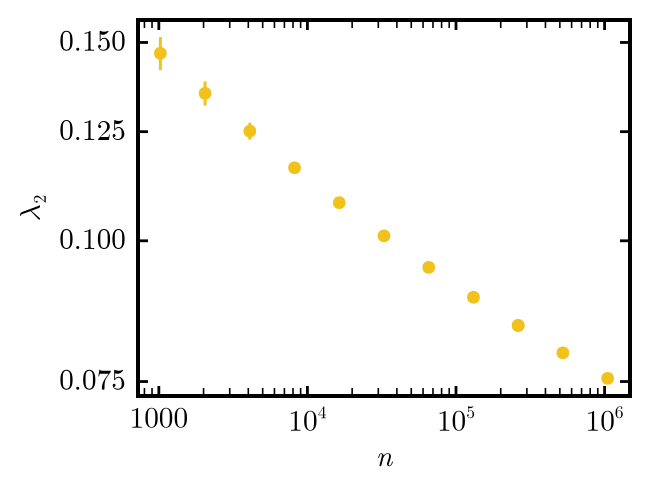

CairoMakie.Screen{PDF}


In [40]:
ys = mean.([res["$(size[1])/second_ev"] for size in size_path_pairs_mink])
errs = std.([res["$(size[1])/second_ev"] for size in size_path_pairs_mink])
xs = [size[1] for size in size_path_pairs_mink]

figsize = apply_paper_theme!(; logscale_x=true, logscale_y=true)
fig = Figure(; size = figsize)
ax = Axis(
    fig[1,1];
    xscale = log10,
    yscale = log10,
    yticks = [0.05, 0.075, 0.1, 0.125, 0.15],
    xlabel = L"n",
    ylabel = L"\lambda_2")
scatter!(ax, xs, ys)
errorbars!(ax, xs, ys, errs)

display(fig)

save(fig_path("graph_observables/second_ev_size_mink.pdf"), fig)

In [50]:
size_path_pairs_mink[11][1]

524288

In [56]:
res["$(size_path_pairs_mink[12][1])/last_ev"]

100-element Vector{Float64}:
 1.4763358569654659
 1.4699067944508317
 1.4847312758024445
 1.472767633246255
 1.4729265630777704
 1.473356620106927
 1.479583583389236
 1.4678071140857116
 1.4777461910756762
 1.4797189738636527
 1.483238957369546
 1.4781464304878127
 1.4773993338630051
 ⋮
 1.4775042060952193
 1.4818100630189954
 1.4786578884256745
 1.481085045560919
 1.4767459966588066
 1.4742186914283435
 1.4779463160750217
 1.4799801044383114
 1.4828699078736456
 1.4783854825489073
 1.4797879171131219
 1.473158026297752

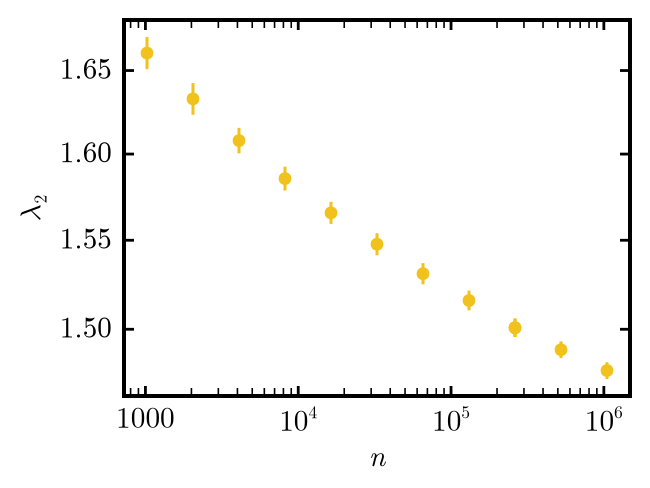

CairoMakie.Screen{PDF}


In [46]:
ys = mean.([res["$(size[1])/last_ev"] for size in size_path_pairs_mink])
errs = std.([res["$(size[1])/last_ev"] for size in size_path_pairs_mink])
xs = [size[1] for size in size_path_pairs_mink]

figsize = apply_paper_theme!(; logscale_x=true, logscale_y=true)
fig = Figure(; size = figsize)
ax = Axis(
    fig[1,1];
    xscale = log10,
    yscale = log10,
    yticks = [1.45,1.5, 1.55,1.6, 1.65],
    xlabel = L"n",
    ylabel = L"\lambda_2")
scatter!(ax, xs, ys)
errorbars!(ax, xs, ys, errs)

display(fig)

save(fig_path("graph_observables/last_ev_size_mink.pdf"), fig)